# MABSTRUCT GAMESTUDIO STUDY SHEET

implementing game studio via LangGraph study

## MABSTRUCT GAMESTUDIO CONCEPT

PRODUCER --> IDEATION --> DESIGN --> DEVELOP <--> TEST --> DEPLOYMENT


In [15]:
# Imports and environment first, as always

import os
import random
import requests
from typing import Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import List

from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver

from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain.agents import create_agent



load_dotenv(override=True)

True

In [2]:
from langsmith import utils

utils.get_env_var.cache_clear()  # clear stale notebook cache

print("tracing:", utils.get_env_var("TRACING") or utils.get_env_var("TRACING_V2"))
print("project:", utils.get_env_var("PROJECT"))
print("endpoint:", utils.get_env_var("ENDPOINT"))
print("api key set:", bool(utils.get_env_var("API_KEY")))

tracing: true
project: GAMESTUDIO-STUDY
endpoint: https://eu.api.smith.langchain.com
api key set: True


In [3]:
# Getting the Telegram bot token and chat ID from environment variables
# You can also replace these with your actual values directly

TELEGRAM_BOT_TOKEN = os.getenv("TELEGRAM_BOT_TOKEN", "your_bot_token_here")
TELEGRAM_CHAT_ID = os.getenv("TELEGRAM_CHAT_ID", "your_chat_id_here")

### verify TELEGRAM token and chat_id are there

if TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID:
    print("TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID found")
else:
    print("TELEGRAM_BOT_TOKEN or TELEGRAM_CHAT_ID not found")



TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID found


In [4]:
def send_telegram_message(text):
    url = f"https://api.telegram.org/bot{TELEGRAM_BOT_TOKEN}/sendMessage"
    payload = {"chat_id": TELEGRAM_CHAT_ID, "text": text}
    print(f"Sending message to Telegram: {text}")
    print(f"TELEGRAM_BOT_TOKEN: {TELEGRAM_BOT_TOKEN}")
    print(f"TELEGRAM_CHAT_ID: {TELEGRAM_CHAT_ID}")
    response = requests.post(url, data=payload)

    if response.status_code == 200:
        # print("Message sent successfully!")
        return {"status": "success", "message": text}
    else:
        # print(f"Failed to send message. Status code: {response.status_code}")
        # print(response.text)
        return {"status": "error", "message": response.text}

In [5]:
# send a test messagex
send_telegram_message(";-)mabstruct games")

Sending message to Telegram: ;-)mabstruct games
TELEGRAM_BOT_TOKEN: [REDACTED]
TELEGRAM_CHAT_ID: [REDACTED]


{'status': 'success', 'message': ';-)mabstruct games'}

In [6]:
class ConversationalState(TypedDict):
    messages: Annotated[list, add_messages]

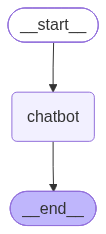

In [7]:
llm = ChatOpenAI(model="gpt-5.4-mini")

def chatbot_node(state: ConversationalState) -> dict:
    return {"messages": [llm.invoke(state["messages"])]}

builder = StateGraph(ConversationalState)
builder.add_node("chatbot", chatbot_node)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
messages = [
    SystemMessage("You are a poetry expert"),
    HumanMessage("Write a haiku about spring"),
    AIMessage("Cherry blossoms bloom...")
]

result = graph.invoke({"messages": messages})
print(result["messages"][-1].content)

Soft rain wakes the soil  
Green shoots lift their sleepy heads  
Spring hums in warm light


In [13]:
agent = create_agent(
    model="openai:gpt-5.4-mini",
    system_prompt="You are an antique greek poet. You write all answers in hexameter verse. You write in the style of Homer. But you write in modern english.",
)

result = agent.invoke({"messages": [{"role": "user", "content": "Explain the concept of a Möbius-transformations."}]})
print(result["messages"][-1].content)

Sing now of lines that bend like war-ships’ prows  
Upon the sea, and keep one law as they turn:  
A Möbius transformation is such a spell,  
A map that takes the wide extended plane  
And turns it by this form:

\[
f(z)=\frac{az+b}{cz+d}
\]

Where \(a,b,c,d\) are numbers,  
And \(ad-bc \neq 0\), lest the form collapse.

It is a kind of motion of the sphere  
Of complex points, preserving many things:  
Circles and straight lines it sends into like forms,  
For lines upon that plane are circles vast,  
And circles small or great remain in kind.  

It keeps the angles true where paths do cross,  
So shapes are twisted, yet their meeting stays  
As once it was, like shields that clash in order.  
These maps are chained by composition as  
The deeds of heroes join in single fate.

It may shift, stretch, turn, or invert as well,  
And where one point goes out to endless sea,  
Another may return from that same brink;  
For this realm includes the point at infinity,  
So no edge bars the co

## Adding tools: a node, a condition, and a loop

To let the model use tools, we add two prebuilt pieces. `ToolNode` is a node that runs whatever tools the model asked for. `tools_condition` is a ready made router that sends the flow to the tools node when the model wants a tool, and to the end when it is finished.

The tools themselves come from two different places, quite deliberately. The search tool comes off the shelf: `langchain-community` ships ready-made tools for hundreds of services, and `GoogleSerperRun` wraps the same Serper API you already have a key for. The push notification tool we write ourselves with the `@tool` decorator, exactly as in lab 1. Notice that both kinds plug into the graph in exactly the same way.

By the way, you may have noticed a deprecation warning when we ran the imports. The `langchain-community` package is gradually being wound down in favor of standalone packages, one per integration, the same way `langchain-openai` ships on its own. It still works well and you will meet it in tutorials all over the web, so it is worth knowing. If you would prefer a fully supported alternative, the `langchain-tavily` package offers a `TavilySearch` tool that does the same job with a free API key from tavily.com.

We bind the tools to the model so it knows they exist, then wire a loop: the chatbot decides, the tools run, and we come back to the chatbot so it can see the results and continue.

In [12]:
from langchain_tavily import TavilySearch
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

search = TavilySearch(max_results=5)

@tool
def send_push_notification(text: str) -> str:
    """Send a short push notification to the user's phone."""
    send_telegram_message(text)
    return "Notification sent"

tools = [search, send_push_notification]
llm_with_tools = llm.bind_tools(tools)

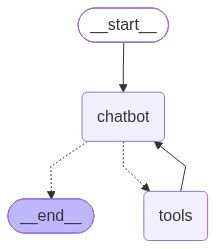

In [13]:
def chatbot_node(state: State) -> dict:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node("chatbot", chatbot_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
result = graph.invoke({"messages": [{"role": "user", "content": "Use your search tool to tell me latest developments in 2025 and 2026 on robotics and physical AI."}]})
print(result["messages"][-1].content)

Here are the main **2025–2026 developments in robotics and “physical AI”** I found from recent sources:

## 1) Robotics foundation models are getting much better at generalization
- **Physical Intelligence (π)** reported a rapid sequence of model advances through 2025 and 2026:
  - **π0.5** (Apr 2025): open-world generalization for a mobile manipulator.
  - **π0.6** (Nov 2025): RL-trained generalist policies with better real-world success/throughput.
  - **π0.7** (Apr 2026): a **steerable model with emergent compositional generalization**, meaning it can follow new language instructions and visual subgoals better than earlier versions.
  - In 2026 they also highlighted **MEM** (Multi-Scale Embodied Memory) and methods for **efficient online RL** to improve long-horizon, precise manipulation.  
  Source: Physical Intelligence blog.

## 2) NVIDIA is pushing a full “physical AI” stack
- At **GTC 2026**, NVIDIA expanded its robotics stack with:
  - **Isaac GR00T N** open models for robotic

In [32]:
GAME_TITLE = "The Big Swallow"

IDEATION_SYSTEM_PROMPT = """
    You are an experienced Creative Strategist for web browser games.
    You have a strong background in browser games ideation and design.
    You bring a wealth of knowledge about single player web browser games.
    You are the one to bring back the best game ideas to the production team of the game studio.
    You are known for your ability to create engaging, creative and fun browser games
    that are both challenging and fun to play. You typically research the web for the latest trends and best games.
    And you are known for your ability to distill the best game ideas from only given a few details, for example only the new game title.
    The studio concentrates on creating single player browser games.
    The attitude of the games is typically creative, inventive and innovative and is slightly surreal and concentrated 
    on sci-fi and cosmic themes.
"""

IDEATION_HUMAN_PROMPT = f"""
    Here is the new game title: {GAME_TITLE}.
    Develop a list of 5 game ideas that are related to the game title.
    You can do this by researching the web for the latest trends and best games.
    Then use your experience as a Creative Strategist to create 5 game ideas for the game studio.
    For each game idea, provide a short description.
    Do some reason what you think is the best game idea from the list.
    Write down the reasoning and the best game idea.
    Then select the best game idea from the list.
    The result will be given to the production and design team of the game studio.
    They will then develop the game idea into a full game.
"""

class GameIdea(BaseModel):
    """
    A game idea is a single game idea for the game studio.
    """
    sub_title: str = Field(description="sub title of the game")
    description: str = Field(description="A short description of the game in 2 to 5 sentences.")

class GameIdeaList(BaseModel):
    """
    A list of game ideas.
    """
    game_ideas: List[GameIdea] = Field(description="A list of 5 game ideas")

class GameIdeaSelection(BaseModel):
    """
    The best game idea from the list.
    """
    game_idea: GameIdea = Field(description="The best game idea from the list")
    reasoning: str = Field(description="The reasoning for the best game idea")

class GameBrief(BaseModel):
    """
    The brief for the game.
    """
    game_title: str = Field(description="The title of the game")
    game_sub_title: str = Field(description="The sub title of the game")
    game_description: str = Field(description="A short description of the game in 2 to 5 sentences.")
    game_genre: str = Field(description="The genre of the game")
    game_theme: str = Field(description="The theme of the game")
    game_style: str = Field(description="The style of the game")
    game_mechanics: str = Field(description="The mechanics of the game")
    game_mood: str = Field(description="The mood of the game")
    game_sound: str = Field(description="The sound of the game")
    game_art: str = Field(description="The art of the game")
    hints_for_the_team: str = Field(description="Hints for the production and design team")

class GameIdeation(BaseModel):
    """
    The ideation for the game.
    """
    game_brief: GameBrief = Field(description="The brief for the game")
    game_ideas: List[GameIdea] = Field(description="A list of 5 game ideas")
    game_idea_selection: GameIdeaSelection = Field(description="The best game idea from the list")

messages_input = [
    HumanMessage(IDEATION_HUMAN_PROMPT),
]

ideation_agent = create_agent(
    model="openai:gpt-5.4-mini",
    system_prompt=IDEATION_SYSTEM_PROMPT,
    response_format=GameIdeation,
)

result = ideation_agent.invoke({"messages": messages_input})
game_ideation = result["structured_response"]
print(game_ideation)
print(game_ideation.game_brief  )
print(game_ideation.game_ideas)
print(game_ideation.game_idea_selection)


game_brief=GameBrief(game_title='The Big Swallow', game_sub_title='A cosmic appetite adventure', game_description='The Big Swallow is a single-player browser game concept built around the surreal idea of consuming, absorbing, or swallowing entire worlds, objects, or phenomena. The title suggests a playful but slightly unsettling power fantasy, which fits well with inventive sci-fi and cosmic themes. The best versions should combine quick decision-making, satisfying progression, and a striking visual identity.', game_genre='Action puzzle / arcade strategy / surreal adventure', game_theme='Cosmic appetite, surreal consumption, strange worlds, absorption, expansion, and transformation', game_style='Stylized browser game with fast sessions, readable feedback, and inventive progression loops', game_mechanics='Swallow-and-grow loop, target prioritization, risk vs reward choices, resource management, evolving abilities, level objectives, hazard avoidance, upgrade paths', game_mood='Playful, b

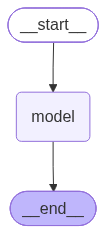

In [40]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [33]:
class GameStudioState(TypedDict):
    game_title: str
    game_ideation: GameIdeation | None
    game_design_md: str | None
    game_html_path: str | None
    test_result: dict | None      # from game_testing.json
    retry_count: int
    deployment_url: str | None

In [34]:
initial_state: GameStudioState = {
    "game_title": GAME_TITLE,
    "game_ideation": None,
    "game_design_md": None,
    "game_html_path": None,
    "test_result": None,
    "retry_count": 0,
    "deployment_url": None,
}

In [ ]:
def ideation_node(state: GameStudioState) -> dict:
    result = ideation_agent.invoke({"messages": [...]})
    return {"game_ideation": result["structured_response"]}

def design_node(state: GameStudioState) -> dict:
    pass
    # pass state["game_ideation"] into the prompt
    

def develop_node(state: GameStudioState) -> dict:
    pass
    # agent with write_game_html + verify tools

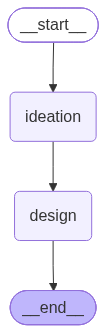

In [36]:
builder = StateGraph(GameStudioState)

builder.add_node("ideation", ideation_node)
builder.add_node("design", design_node)

builder.add_edge(START, "ideation")
#builder.add_conditional_edges("chatbot", tools_condition, {"tools": "tools", END:"translator"})
builder.add_edge("ideation", "design")
builder.add_edge("design", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
result = graph.invoke(initial_state)
print(result["game_ideation"])


NotImplementedError: Unsupported message type: <class 'ellipsis'>
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/MESSAGE_COERCION_FAILURE 

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/tools.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#00bfff;">Observability with LangSmith</h2>
            <span style="color:#00bfff;">LangSmith records every model and tool call so you can see exactly what your graph did. Sign up at <a href="https://smith.langchain.com">smith.langchain.com</a>, create an API key, and add these lines to your <code>.env</code> file:<br/><br/>
            <code>LANGSMITH_TRACING=true</code><br/>
            <code>LANGSMITH_ENDPOINT=https://api.smith.langchain.com</code></br>
            <code>LANGSMITH_API_KEY=lsv2_...</code><br/>
            <code>LANGSMITH_PROJECT=agentic-track</code><br/><br/>
            That is all. Every LangChain and LangGraph run is then traced automatically with no change to your code, and you can watch it unfold on the LangSmith dashboard. We will not run this here, but it is well worth turning on for your own work.
            </span>
        </td>
    </tr>
</table>

In [17]:
# Now load the env again if you added LangSmith variables

load_dotenv(override=True)

True

## Memory: why the graph forgets, and how to fix it

Try chatting twice with the graph above and it will not remember the first exchange. That feels odd, because the state was carefully passing messages along. The reason is that one call to `invoke` is one run of the graph: a sequence of super-steps, one for each layer of nodes that executes (the LLM call is one super-step; the tool calls it requests run together in the next). The reducer accumulates messages within that run, but the next `invoke` starts fresh.

To remember across calls we add a checkpointer. It saves a snapshot of the state after every super-step, filed under a `thread_id`. Give it the same `thread_id` next time and the saved history is loaded before your new message is added.

In [ ]:
memory = MemorySaver()

builder = StateGraph(State)
builder.add_node("chatbot", chatbot_node)
builder.add_node("tools", ToolNode(tools))
builder.add_node("translator", translator_node)
builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition, {"tools": "tools", END: "translator"})
builder.add_edge("translator", END)
builder.add_edge("tools", "chatbot")
graph = builder.compile(checkpointer=memory)


config = {"configurable": {"thread_id": "conversation-1"}}
graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Ed."}]}, config)
second = graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)
print(second["messages"][-1].content)
print(second["spanish"])

## Persisting to SQLite

`MemorySaver` keeps everything in memory, which vanishes when the program stops. For something durable we swap in the SQLite checkpointer, which writes to a database file. The same graph code now survives restarts. A file called `memory.db` appears next to this notebook, and you can delete it whenever you like.

In [ ]:
with SqliteSaver.from_conn_string("memory.db") as sql_memory:
    durable_graph = builder.compile(checkpointer=sql_memory)
    sql_config = {"configurable": {"thread_id": "conversation-2"}}
    durable_graph.invoke({"messages": [{"role": "user", "content": "Remember that my favorite color is orange."}]}, sql_config)
    reply = durable_graph.invoke({"messages": [{"role": "user", "content": "What is my favorite color?"}]}, sql_config)
    print(reply["messages"][-1].content)
    print(reply["spanish"])

## Looking inside the state, and travelling back in time

Because the checkpointer saves a snapshot at every super-step, you can inspect the current state and walk the whole history. Each entry carries a `checkpoint_id`, and by putting one of those into the config you can rerun the graph from that exact moment. This is what lets LangGraph applications recover and branch from any earlier point.

In [ ]:
snapshot = graph.get_state(config)
messages = snapshot.values["messages"]
print("Messages stored so far:", len(messages))

for message in messages:
    print(message.content)

history = list(graph.get_state_history(config))
print("Number of saved checkpoints:", len(history))


In [ ]:
for h in reversed(history):            # history is newest first; reversed reads as a story
      m = h.metadata
      queued = ", ".join(t.name for t in h.tasks) or "(run complete)"
      print(f"step {m['step']:>2}  {m['source']:<5}  messages={len(h.values.get('messages', []))}  about to run: {queued}")

In [ ]:
# Time travel: take a checkpoint from earlier and resume the graph from that exact moment
earlier = history[len(history) // 2]
print("A checkpoint from earlier held", len(earlier.values["messages"]), "messages")

replay_config = {"configurable": {"thread_id": "conversation-1",
                                  "checkpoint_id": earlier.config["configurable"]["checkpoint_id"]}}
resumed = graph.invoke(None, replay_config)
print("Resumed from the past; the graph now holds", len(resumed["messages"]), "messages")

again = graph.invoke({"messages": [{"role": "user", "content": "What do you know about me?"}]}, replay_config)
print(again["messages"][-1].content)
print(again["spanish"])


## Adding a UI

Let's add a simple Gradio UI to bring this to life. The `chat` function kicks off one run of the graph per message, using a fixed `thread_id` so the conversation is remembered, and it shows the Spanish translation in italics beneath each reply.

In [ ]:
def chat(user_input: str, history):
    config = {"configurable": {"thread_id": "gradio-session4"}}
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config)
    return f"{result['messages'][-1].content}\n\n*{result['spanish']}*"

gr.ChatInterface(chat).launch()

## Recap, and where we are heading

You have built graphs by hand: state with a reducer, nodes, edges, a conditional edge, a tool loop, a second LLM node, observability, memory in two flavors, and a way to inspect and replay the whole thing. This is the machinery that powers everything above it.

Tomorrow we reach Layer 3, our next step along the control to convenience spine. We will ask `create_agent` to build a graph exactly like the tool loop above, in a single line, and then we will render that graph and recognise it as our own.

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/exercise.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Exercise</h2>
            <span style="color:#ff7800;">Add a third tool to the graph, then ask the assistant a question that needs a search followed by a push notification and uses your tool, so the tool loop runs more than once. Then open the LangSmith dashboard, if you turned it on, and trace exactly which nodes ran and in what order.
            </span>
        </td>
    </tr>
</table>